In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Load the dataset and memory optimize

In [41]:
dtypes = {'cc_num': 'int64', 'merchant': 'category', 'category': 'category',
          'amt': 'float32', 'is_fraud': 'int8', 'state': 'category'}
df = pd.read_csv('credit_card_transactions.csv', dtype=dtypes, parse_dates=['trans_date_trans_time'])

print(f'Shape: {df.shape}, Fraud rate:{df["is_fraud"].mean():.2%}')

Shape: (1296675, 24), Fraud rate:0.58%


Data cleaning

In [42]:
# Handle missing values
df = df.dropna()
# Remove duplicates
df = df.drop_duplicates()
# Age column
df['dob'] = pd.to_datetime(df['dob'], format='%Y-%m-%d', errors='coerce')
df['age'] = 2026 - df['dob'].dt.year
# City pop
df['city_pop'] = pd.to_numeric(df['city_pop'], errors='coerce')
# Transaction hour
df['hour'] = pd.to_datetime(df['trans_date_trans_time'], errors='coerce').dt.hour

EDA plot

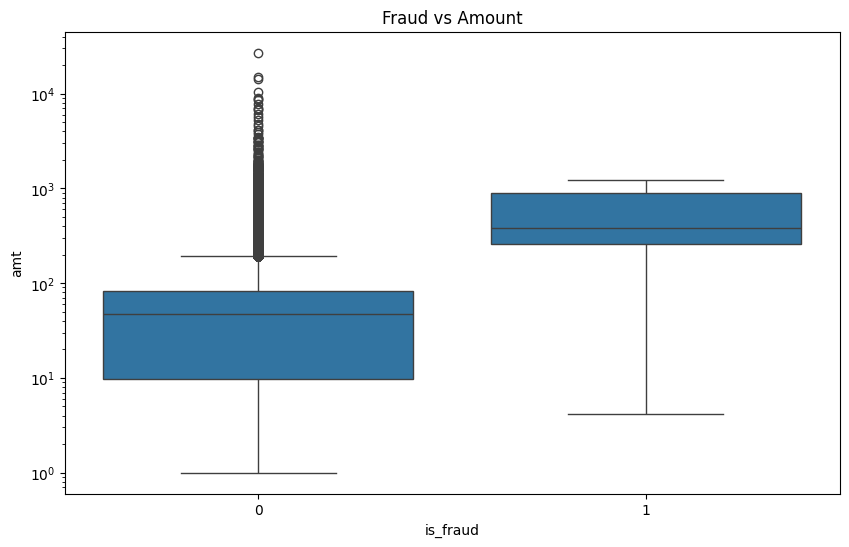

Data cleaned df.shape: (1100702, 26)


In [43]:
sample_df = df.sample(100000, random_state=42)

plt.figure(figsize=(10, 6))
sns.boxplot(x='is_fraud', y='amt', data=sample_df)
plt.yscale('log')
plt.title('Fraud vs Amount')
plt.savefig('fraud_amount.png', dpi=300)
plt.show()

print("Data cleaned df.shape:", df.shape)
df.to_csv('cleaned_transactions.csv', index=False)

Fraud vs Category plot

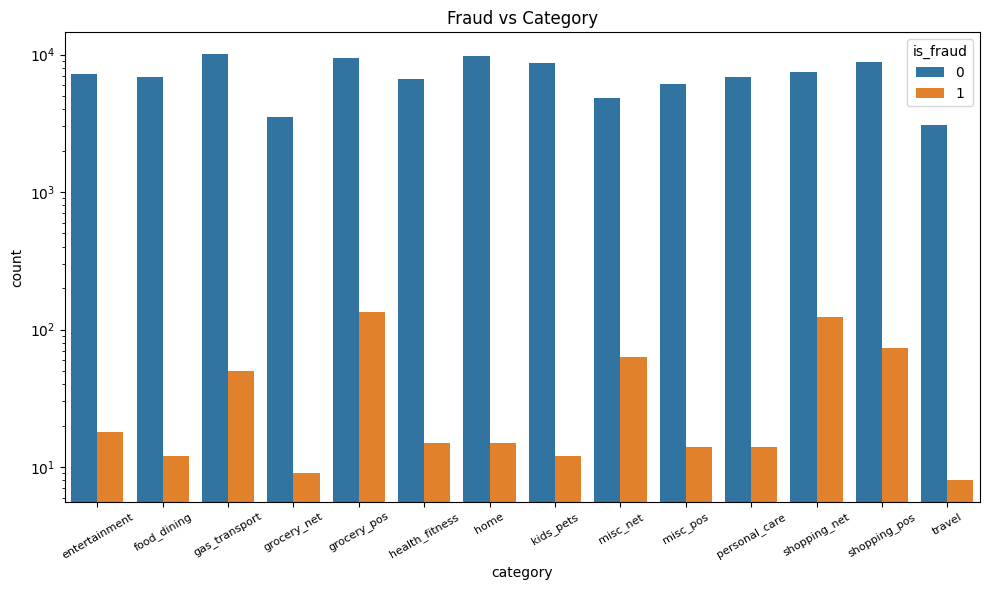

In [44]:
plt.figure(figsize=(10, 6))
sns.countplot(x = 'category', hue = 'is_fraud', data = sample_df)
plt.yscale('log')
plt.xticks(rotation = 30, fontsize=8)
plt.title('Fraud vs Category')
plt.tight_layout()
plt.savefig('fraud_category.png', dpi=300)
plt.show()

Age vs Fraud plot

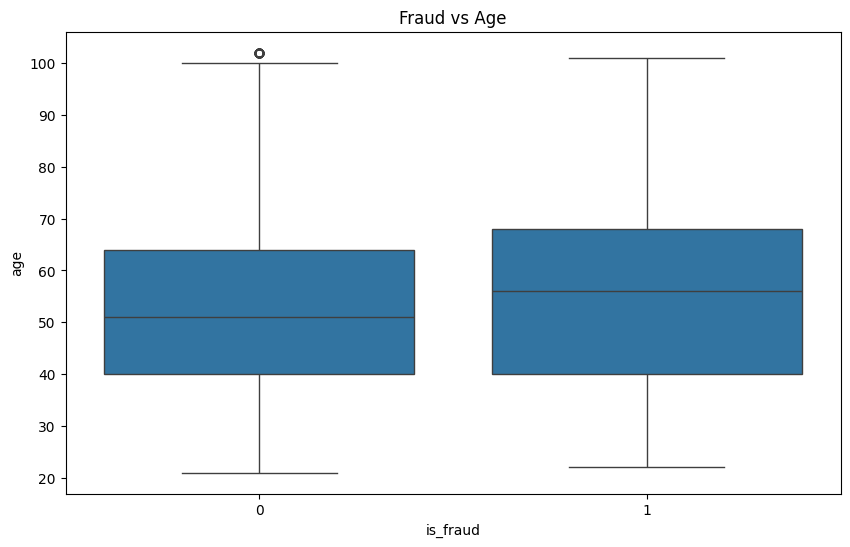

In [45]:
sample_df = sample_df.dropna(subset=['age'])
plt.figure(figsize=(10, 6))
sns.boxplot(x = 'is_fraud', y ='age', data = sample_df )
plt.title('Fraud vs Age')
plt.savefig('fraud_age.png', dpi=300)
plt.show()

Fraud Amount by Hour plot

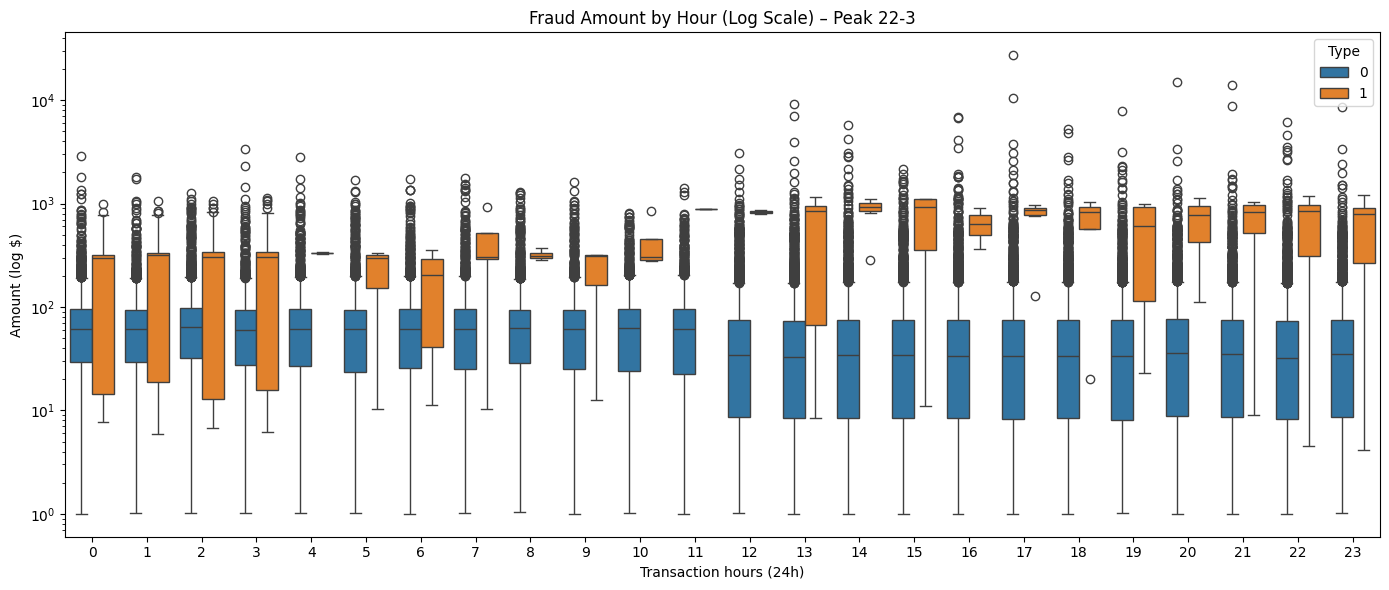

Fraud after hour:
 hour
0    540
1    564
2    536
3    520
4     40
5     47
6     34
7     46
8     42
9     37
Name: count, dtype: int64
Worst 5 hours:
 hour
22    1637
23    1604
1      564
0      540
2      536
Name: count, dtype: int64


In [46]:
plt.figure(figsize=(14,6))
sns.boxplot(x='hour', y='amt', hue='is_fraud', data=sample_df)
plt.yscale('log')  # Log scale - better visibility
plt.title('Fraud Amount by Hour (Log Scale) – Peak 22-3')
plt.xlabel('Transaction hours (24h)')
plt.ylabel('Amount (log $)')
plt.legend(title='Type')
plt.tight_layout()
plt.savefig('fraud_hour.png', dpi=300)
plt.show()

df_fraud = df[df['is_fraud']==1]
hour_fraud = df_fraud['hour'].value_counts().sort_index()
print('Fraud after hour:\n', hour_fraud.head(10))
print('Worst 5 hours:\n', hour_fraud.nlargest(5))

Fraud RATE by hour

In [47]:
hour_stats = df.groupby('hour')['is_fraud'].agg(['count', 'mean']).round(4)
print('Fraud RATE by hour:\n', hour_stats.sort_values(by ='mean', ascending=False).head(10)) # mean *100 (%)


Fraud RATE by hour:
       count    mean
hour               
22    56675  0.0289
23    56772  0.0283
1     36489  0.0155
0     36242  0.0149
2     36354  0.0147
3     36452  0.0143
14    54963  0.0013
7     36072  0.0013
19    55257  0.0013
13    55301  0.0013


Fraud RATE plot

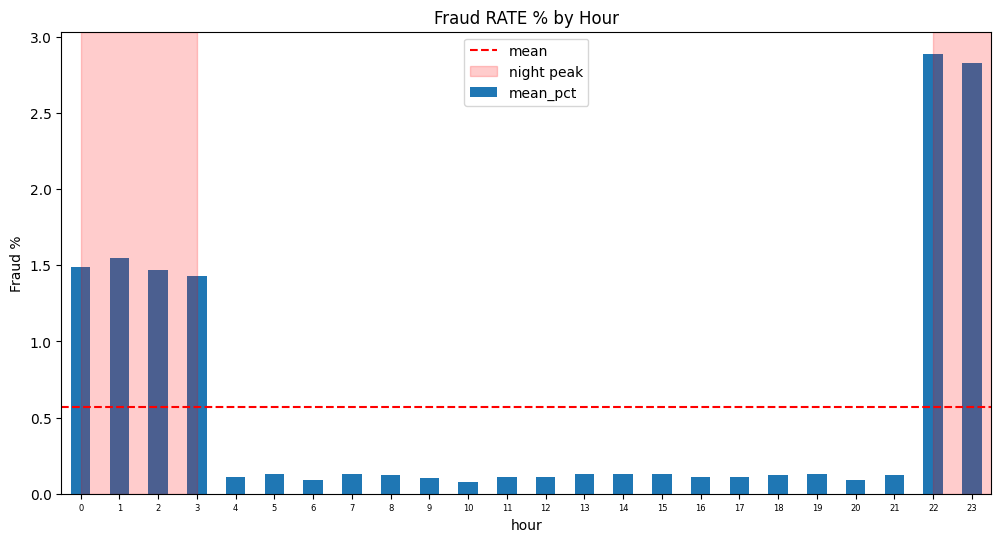

In [48]:
hour_stats = hour_stats.reset_index()
hour_stats['mean_pct'] = hour_stats['mean'] * 100
hour_stats.plot(x='hour', y='mean_pct' , kind='bar', figsize=(12,6))
plt.title('Fraud RATE % by Hour')
plt.ylabel('Fraud %')
plt.xticks(rotation = 0, fontsize=6)
plt.axhline(y=hour_stats['mean'].mean()*100, color='red', linestyle='--', label='mean')
plt.axvspan(22, 24, alpha=0.2, color='red', label='night peak')
plt.axvspan(0, 3, alpha=0.2, color='red')
plt.legend()
plt.savefig('fraud_rate.png', dpi=300)
plt.show()

FRAUD DETECTION MODEL

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
import  warnings
warnings.filterwarnings('ignore')

FEATURES

In [50]:
features = ['amt', 'hour', 'city_pop', 'age']

X = sample_df[features].fillna(sample_df[features].median()) # Fix NaN
y = sample_df['is_fraud']

TRAIN/TEST split

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

SCALER

In [52]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Logistic Regression

In [53]:
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

Predictions

In [54]:
y_pred = lr_model.predict(X_test_scaled)
y_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

Metrics

In [55]:
print(f'\nModel Performance: \n{classification_report(y_test, y_pred)}')
print(f'ROC AUC: \n{roc_auc_score(y_test, y_proba):.3f}')

print(f'Confusion Matrix (frauds detected):\n{confusion_matrix(y_test, y_pred)}')


Model Performance: 
              precision    recall  f1-score   support

           0       1.00      0.95      0.98     19888
           1       0.08      0.72      0.14       112

    accuracy                           0.95     20000
   macro avg       0.54      0.84      0.56     20000
weighted avg       0.99      0.95      0.97     20000

ROC AUC: 
0.810
Confusion Matrix (frauds detected):
[[18955   933]
 [   31    81]]


FEATURE Importance

In [56]:
importances = pd.DataFrame(
    {
        'Feature': features,
        'Importance': lr_model.coef_[0]
    }
).sort_values(by='Importance', ascending=False, key=abs)
print(f'\nMost important Features:\n{importances.head(10)}')


Most important Features:
    Feature  Importance
0       amt    1.485345
1      hour   -0.169933
2  city_pop   -0.122313
3       age    0.045239


ROC + Confusion Matrix visualization

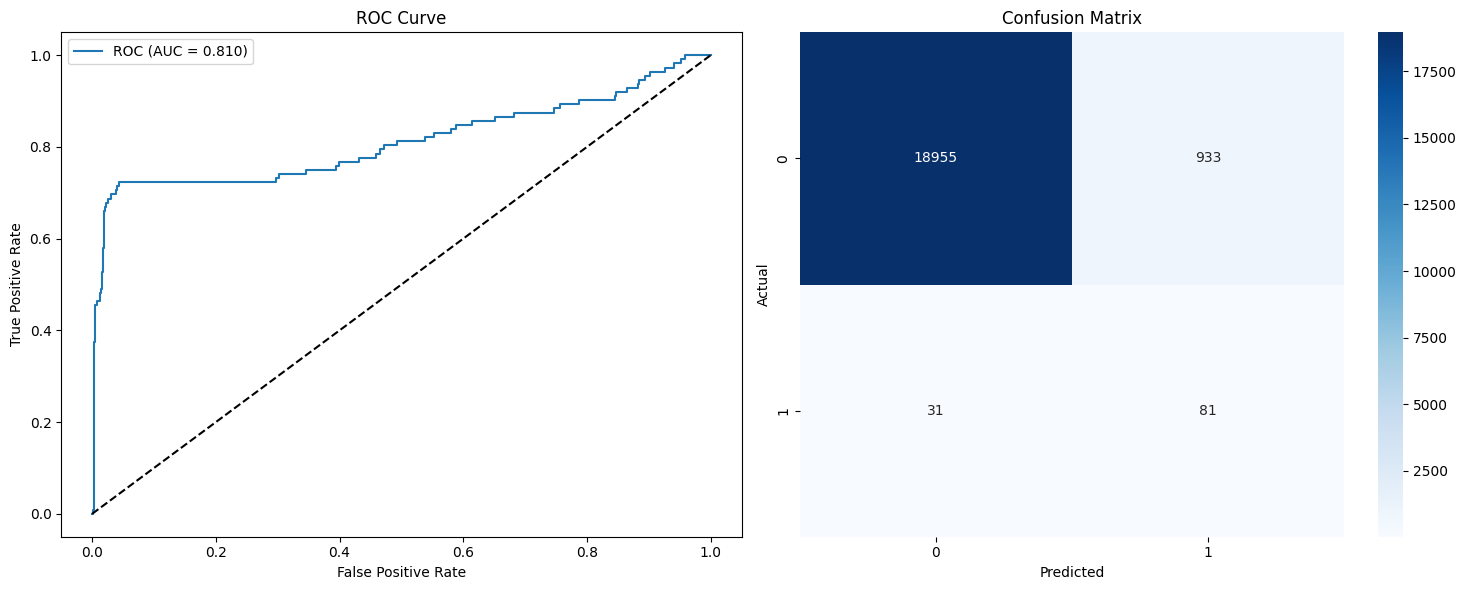

In [57]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ROC Curve
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_proba)
ax1.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc_score(y_test, y_proba):.3f})')
ax1.plot([0, 1], [0, 1], 'k--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend()

# Confusion Matric heatmap
sns.heatmap(data=confusion_matrix(y_test, y_pred), annot=True, fmt='d', ax=ax2, cmap='Blues')
ax2.set_title('Confusion Matrix')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('fraud_model_results.png', dpi=300)
plt.show()